In [1]:
import os
import random
import time
from datetime import date
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#DATA_PATH = "./data/2025-07-15_full_training_data_98066_samples.csv" # carbons log-uniform, others uniform
DATA_PATH = "./data/2025-07-22_full_training_data_29446_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_19637_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_9844_samples.csv" # carbons log-uniform, others uniform
#datafile = "./data/2025-07-15_full_training_data_99518_easy_samples.csv" #log-uniform samples

In [3]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:

if torch.backends.mps.is_available():
    device = torch.device('mps')  # Mac Metal Performance Shaders
    print(f"Training on device: {device} (Mac GPU)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Training on device: {device} (NVIDIA GPU)")
else:
    device = torch.device('cpu')
    print(f"Training on device: {device} (CPU)")

print(f"PyTorch version: {torch.__version__}")


#device = torch.device("cpu")

Training on device: cuda (NVIDIA GPU)
PyTorch version: 2.5.1+cu121


In [5]:
def print_gpu_memory():
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'Allocated memory: {allocated:.2f} MB')
        print(f'Reserved memory: {reserved:.2f} MB')
    else:
        print("CUDA is not available.")

In [6]:

class AttentionBlock(nn.Module):
    """Multi-head attention block for metabolic modeling with context """
    def __init__(self, d_model=6, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
            # return averaged attention weights
        )
        # c projection to match d_model
        self.Wc_proj = nn.Linear(1, d_model, bias=False)
        # Project back to original c_dim=1
        self.Wc_out = nn.Linear(d_model, 1, bias=False)

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)

        # Normalize and self-attend x
        x_norm = self.layer_norm(x)
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True)
        # attn_out: (B, S, d_model)
        # attn_weights: (B, S, S) averaged over heads

        x_out = attn_out + x

        # Cross-attend concentrations c using same attention weights
        # Project c into d_model space
        c_proj = self.Wc_proj(c)            # (B, S, d_model)
        # Apply attention weights: (B, S, S) @ (B, S, d_model) -> (B, S, d_model)
        # need to batch-matmul with proper dims
        c_att = torch.bmm(attn_weights, c_proj)
        # Project back to scalar per position
        c_out = self.Wc_out(c_att) + c      # (B, S, 1)

        return x_out, c_out


In [7]:
class FeedForwardBlock(nn.Module):

    def __init__(self, d_model, inner_dim_multiplier, dropout=0.1):
        super(FeedForwardBlock, self).__init__()

        self.d_model = d_model + 1
        self.inner_dim = inner_dim_multiplier * (d_model + 1)

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.inner_dim)
        #self.activation = nn.ReLU()
        self.activation = nn.LeakyReLU(0.01)
        self.linear2 = nn.Linear(self.inner_dim, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        #hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [8]:
class FluxTransformerBlock(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=6, n_heads=2, inner_dim_multiplier=5, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, inner_dim_multiplier, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        # Process through attention block
        attn_x, attn_c = self.attention_block(x, c)
        
        # Process through feedforward block
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]  # embeddings portion
        updated_c = ff_output[:, :, -1:]  # context portion
        
        return updated_x, updated_c

In [9]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=115,
        d_model=6,
        n_heads=2,
        n_layers=4,
        inner_dim_multiplier=5,
        dropout=0.1
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        
        # Single shared embedding layer
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        
        # Create transformer blocks
        self.blocks = nn.ModuleList([
            FluxTransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                inner_dim_multiplier=inner_dim_multiplier,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c):
        batch_size = c.size(0)
        
        # Create token indices once
        y = torch.arange(self.vocab_size, device=c.device)
        y = y.unsqueeze(0).expand(batch_size, -1)  # (batch, seq)
        
        # Embed tokens once
        x = self.input_embedding(y)  # (batch, seq, d_model)
        
        for block in self.blocks:
            x, c = block(x, c)
        
        # Final output is the context vector
        return c

In [10]:
def load_data(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    all_columns = inputs + outputs
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, all_columns

In [11]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Optional: standardize inputs (only input features, i.e., first 20 columns)
    # scaler = StandardScaler()
    # X_train[:, :20] = scaler.fit_transform(X_train[:, :20])
    # X_test[:, :20] = scaler.transform(X_test[:, :20])

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [12]:
set_seed()

X, y, columns = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 29446 samples from ./data/2025-07-22_full_training_data_29446_samples.csv
Number of input features: 20
Number of output targets: 95
Training samples: 17667
Test samples: 11779


In [13]:
X_train.size(), y_train.size(), len(columns)

(torch.Size([17667, 115]), torch.Size([17667, 115]), 115)

In [14]:
def train_model(d_model=6, n_heads=2, n_layers=2, inner_dim_multiplier=5, 
               batch_size=128, num_epochs=1000, learning_rate=0.001):
    # Create datasets with correct dimensions
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = FluxTransformer(
        vocab_size=115,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        inner_dim_multiplier=inner_dim_multiplier
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    #criterion = nn.MSELoss()
    criterion = nn.HuberLoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            torch.cuda.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                torch.cuda.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        # Additional memory cleanup after epoch
        torch.cuda.empty_cache()
        gc.collect()

    return train_losses, test_losses, model

In [15]:
def plot_loss_curves(train_losses, test_losses, d_model, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Training and Test Loss for d_model = {d_model}", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    plt.show()

In [16]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of actuals"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [17]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    pred = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,0].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_flux(
    model,
    X_test,
    y_test,
    columns,
    flux_name: str,
    device: torch.device,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""
    output_cols = columns[20:]
    X_test_ = X_test.unsqueeze(-1)

    model.eval()
    with torch.no_grad():
        y_pred_tensor = model(X_test_.to(device))  # shape: [n_samples, 115, 1]
    print("y_pred_tensor.shape:", y_pred_tensor.shape)

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    print("y_pred_full.shape:", y_pred_full.shape,
            "min/max:", y_pred_full.min(), y_pred_full.max())

    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]
    print("y_true_full.shape:", y_true_full.shape,
            "min/max:", y_true_full.min(), y_true_full.max())

    # Extract only the output predictions (last 95 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify we have the correct column
    print(f"Flux column index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for biomass
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

Allocated memory: 25.84 MB
Reserved memory: 40.00 MB
Epoch 50/1000 | Train Loss: 1.521725 | Test Loss: 1.409868
Epoch 100/1000 | Train Loss: 1.329473 | Test Loss: 1.239046
Epoch 150/1000 | Train Loss: 1.242482 | Test Loss: 1.162838
Epoch 200/1000 | Train Loss: 1.195456 | Test Loss: 1.150666
Epoch 250/1000 | Train Loss: 1.170050 | Test Loss: 1.121759
Epoch 300/1000 | Train Loss: 1.149564 | Test Loss: 1.115132
Epoch 350/1000 | Train Loss: 1.139503 | Test Loss: 1.099110
Epoch 400/1000 | Train Loss: 1.131332 | Test Loss: 1.094757
Epoch 450/1000 | Train Loss: 1.120524 | Test Loss: 1.089736
Epoch 500/1000 | Train Loss: 1.118288 | Test Loss: 1.129552
Epoch 550/1000 | Train Loss: 1.112191 | Test Loss: 1.073039
Epoch 600/1000 | Train Loss: 1.104873 | Test Loss: 1.074718
Epoch 650/1000 | Train Loss: 1.102094 | Test Loss: 1.100250
Epoch 700/1000 | Train Loss: 1.094333 | Test Loss: 1.070412
Epoch 750/1000 | Train Loss: 1.089709 | Test Loss: 1.052399
Epoch 800/1000 | Train Loss: 1.081235 | Test Los

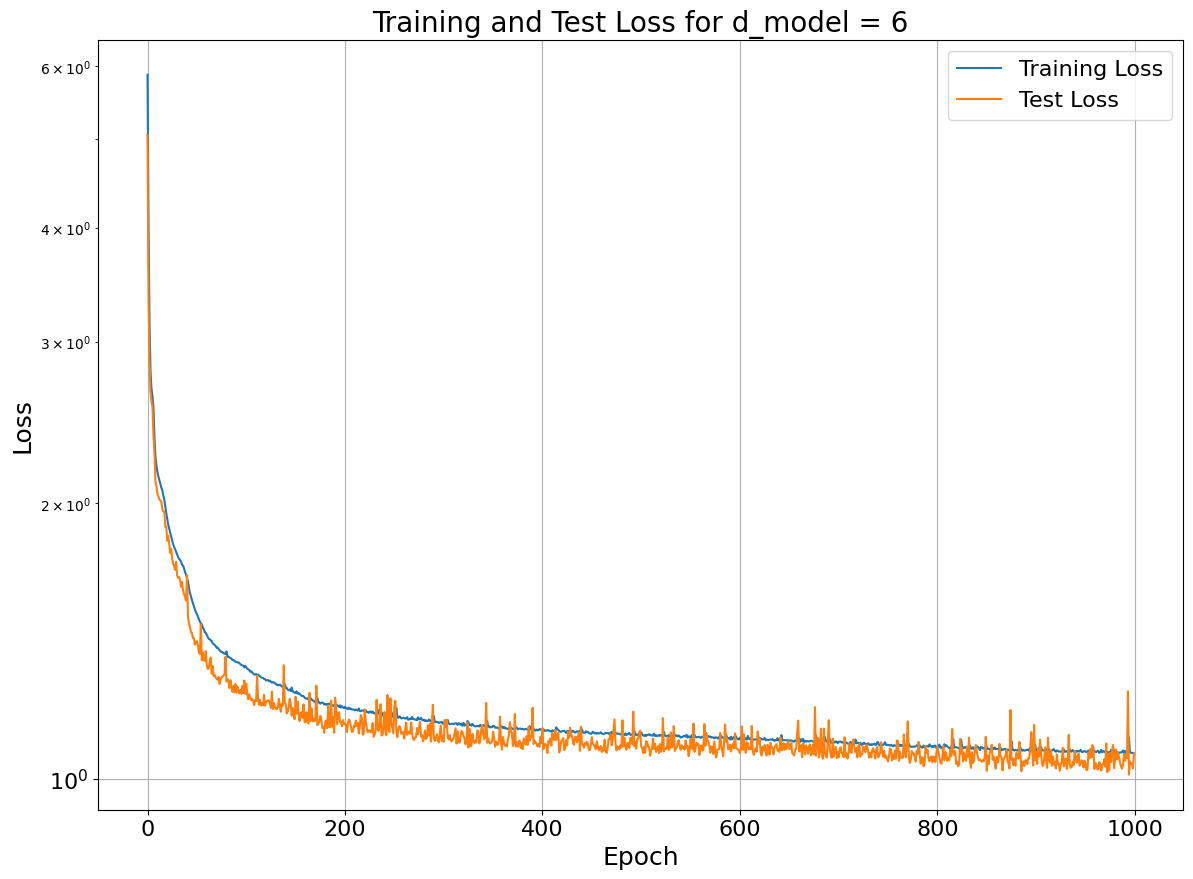

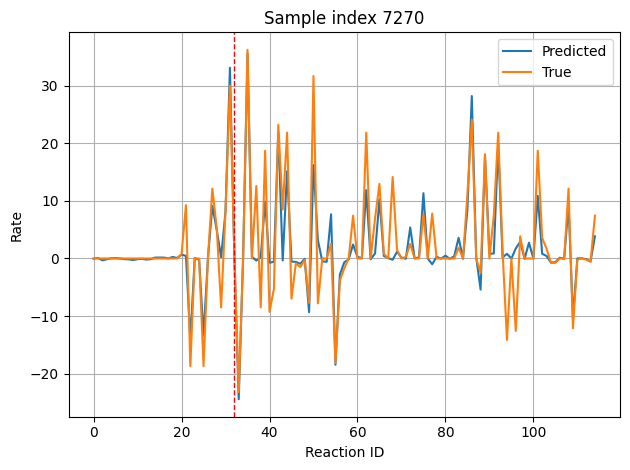

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -60.3213 100.2793
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -60.3213 100.2793
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -1.2746861 to 2.1129024


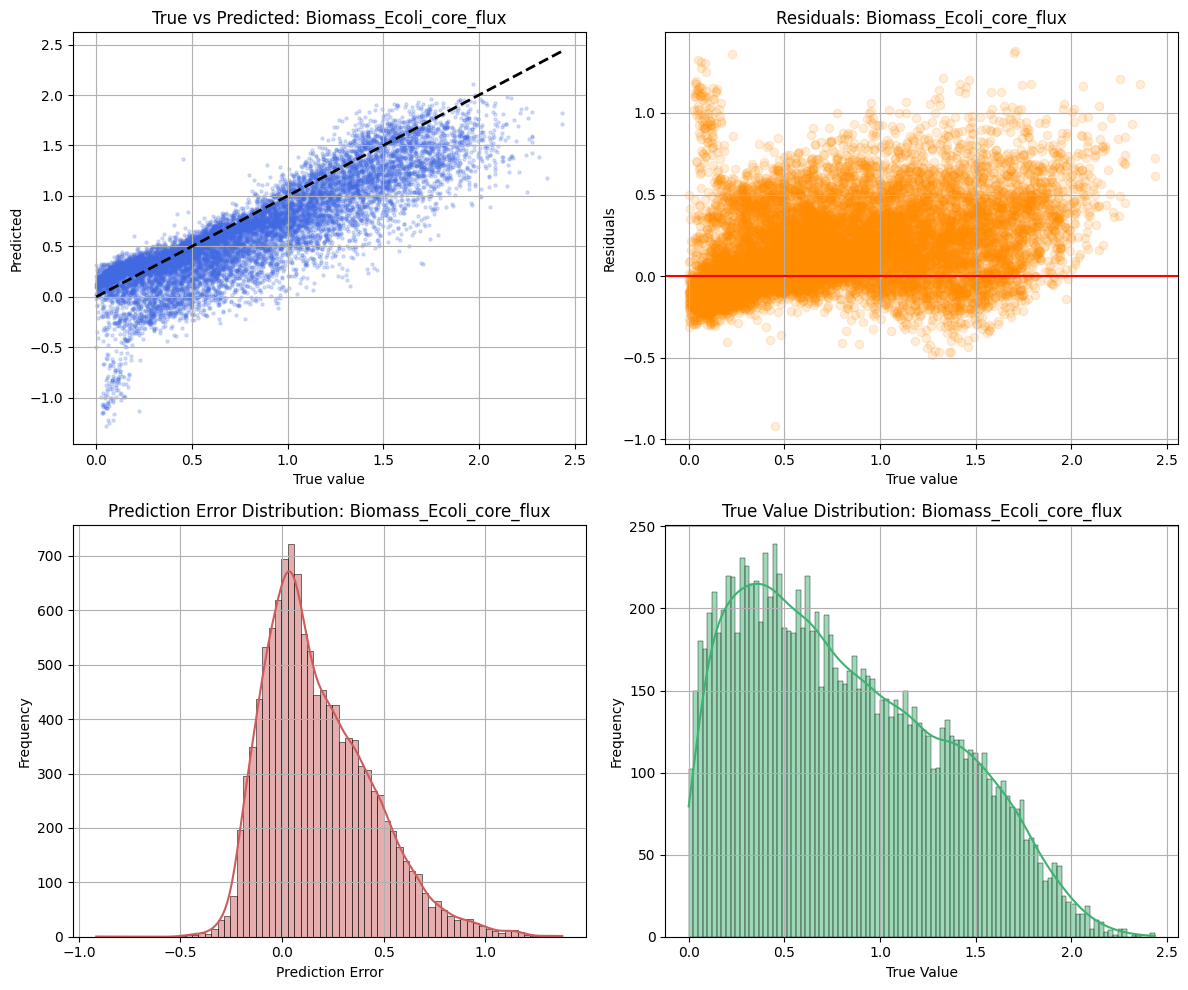

Number of parameters:
2166


In [19]:
print_gpu_memory()

train_losses, test_losses, trained_model = train_model(d_model=6, n_heads=2, n_layers=2, inner_dim_multiplier=5)

plot_loss_curves(train_losses, test_losses, d_model=6)

plot_prediction_sample(X_test, y_test, trained_model)

plot_flux(trained_model, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model.parameters() if p.requires_grad  ))

Epoch 50/1000 | Train Loss: 1.153551 | Test Loss: 1.207994
Epoch 100/1000 | Train Loss: 0.979357 | Test Loss: 0.912021
Epoch 150/1000 | Train Loss: 0.887332 | Test Loss: 0.820443
Epoch 200/1000 | Train Loss: 0.821869 | Test Loss: 0.758877
Epoch 250/1000 | Train Loss: 0.781717 | Test Loss: 0.724587
Epoch 300/1000 | Train Loss: 0.746625 | Test Loss: 0.668848
Epoch 350/1000 | Train Loss: 0.732678 | Test Loss: 0.661375
Epoch 400/1000 | Train Loss: 0.717935 | Test Loss: 0.660506
Epoch 450/1000 | Train Loss: 0.708901 | Test Loss: 0.690906
Epoch 500/1000 | Train Loss: 0.703525 | Test Loss: 0.798241
Epoch 550/1000 | Train Loss: 0.691319 | Test Loss: 0.596935
Epoch 600/1000 | Train Loss: 0.683631 | Test Loss: 0.751777
Epoch 650/1000 | Train Loss: 0.677103 | Test Loss: 0.587497
Epoch 700/1000 | Train Loss: 0.676143 | Test Loss: 0.589209
Epoch 750/1000 | Train Loss: 0.673955 | Test Loss: 0.754122
Epoch 800/1000 | Train Loss: 0.672748 | Test Loss: 0.607016
Epoch 850/1000 | Train Loss: 0.685702 | T

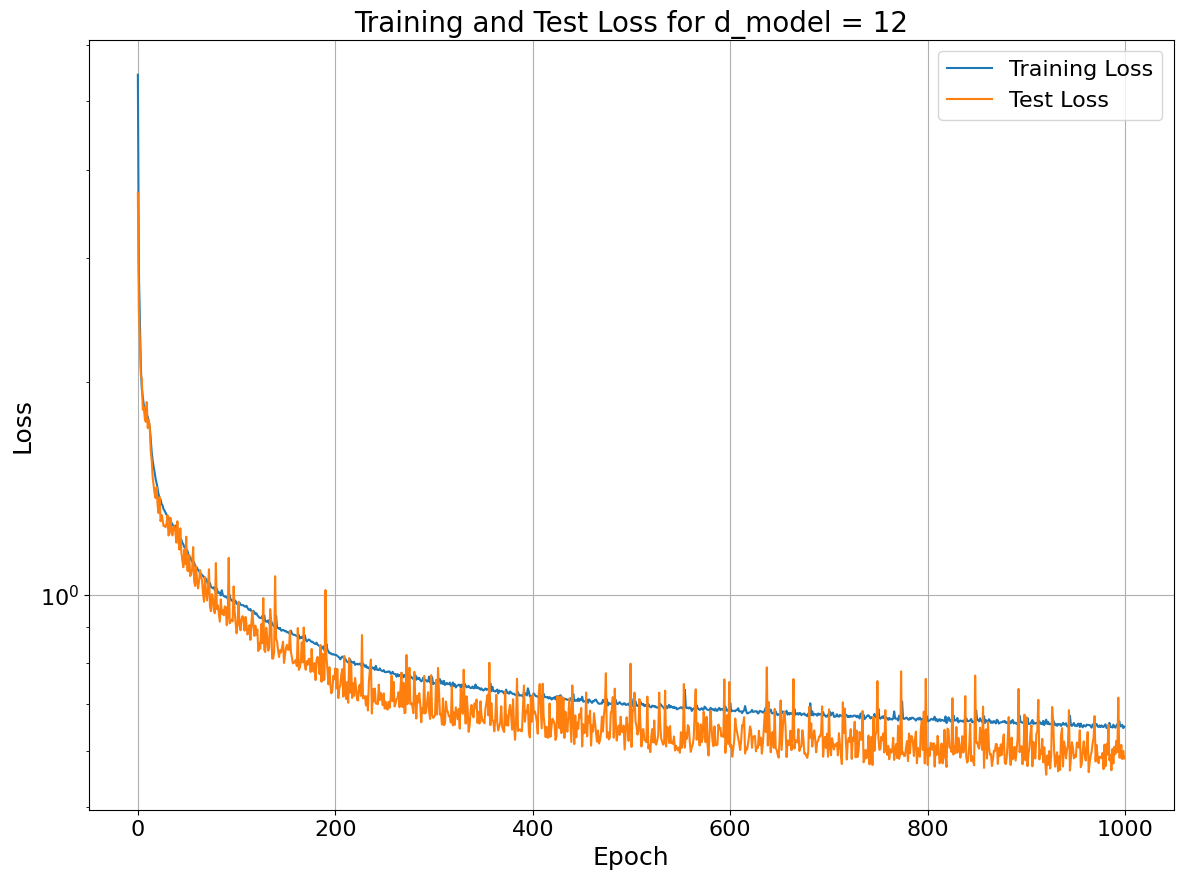

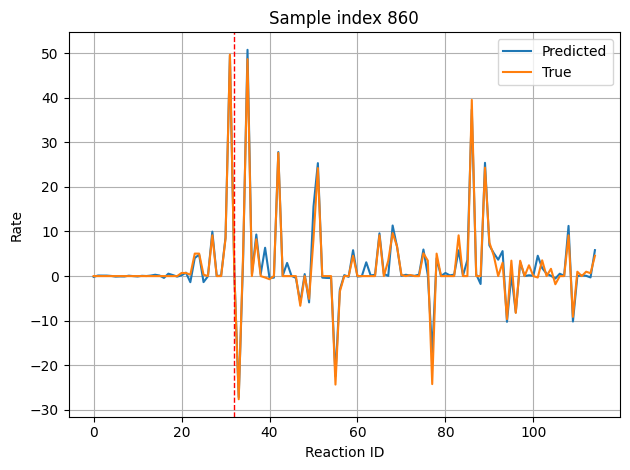

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -75.59546 106.76193
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -75.59546 106.76193
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -1.0096377 to 3.9393172


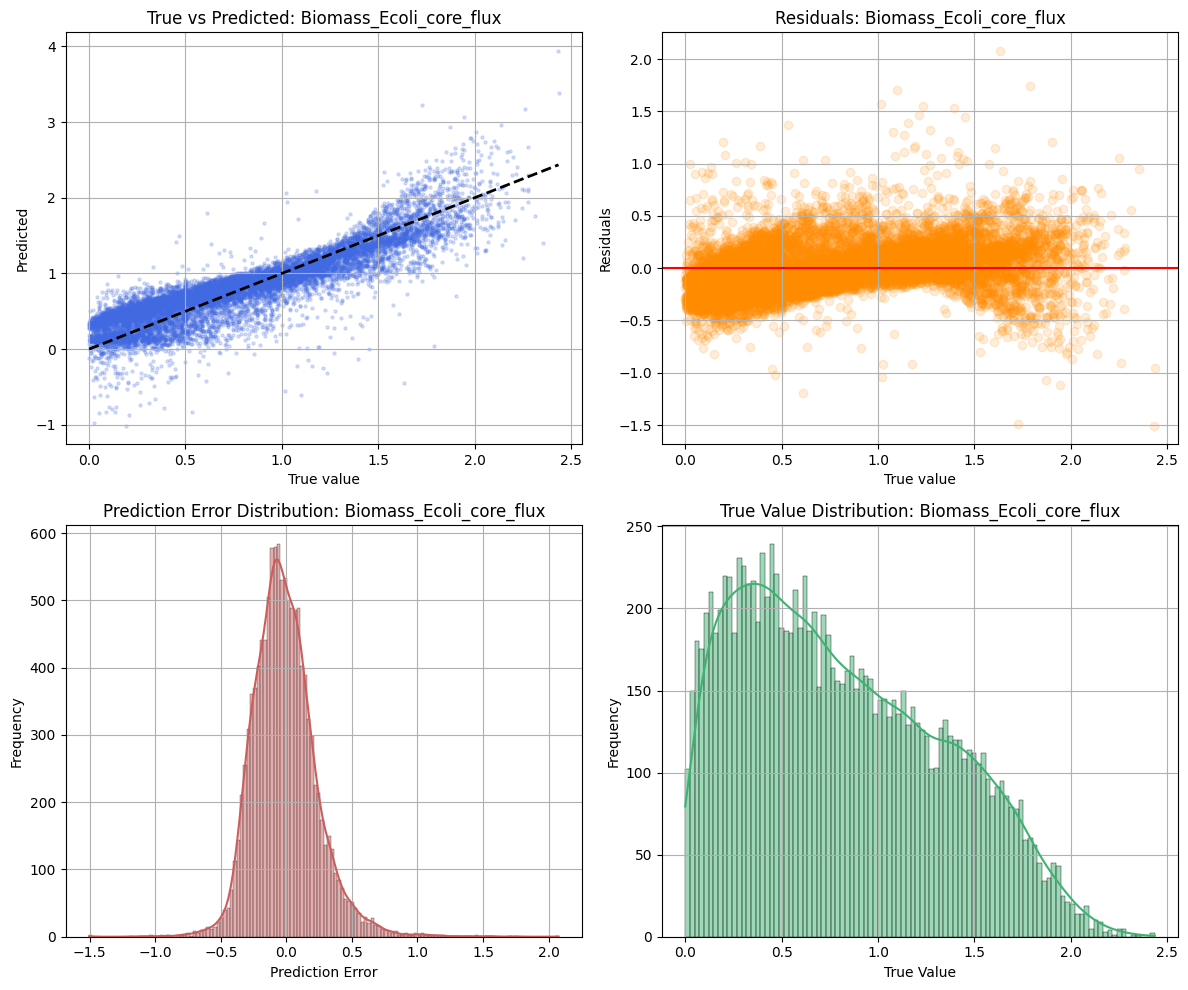

Number of parameters:
6312


In [20]:
train_losses_12_3_2_5, test_losses_12_3_2_5, trained_model_12_3_2_5 = train_model(d_model=12, n_heads=3, n_layers=2, inner_dim_multiplier=5)

plot_loss_curves(train_losses_12_3_2_5, test_losses_12_3_2_5, d_model=12)

plot_prediction_sample(X_test, y_test, trained_model_12_3_2_5)

plot_flux(trained_model_12_3_2_5, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_12_3_2_5.parameters() if p.requires_grad  ))

Epoch 50/1000 | Train Loss: 0.972469 | Test Loss: 0.874536
Epoch 100/1000 | Train Loss: 0.779995 | Test Loss: 0.702918
Epoch 150/1000 | Train Loss: 0.695282 | Test Loss: 0.673835
Epoch 200/1000 | Train Loss: 0.662099 | Test Loss: 0.616094
Epoch 250/1000 | Train Loss: 0.624405 | Test Loss: 0.631796
Epoch 300/1000 | Train Loss: 0.595432 | Test Loss: 0.534395
Epoch 350/1000 | Train Loss: 0.574143 | Test Loss: 0.521487
Epoch 400/1000 | Train Loss: 0.560658 | Test Loss: 0.487193
Epoch 450/1000 | Train Loss: 0.552702 | Test Loss: 0.490009
Epoch 500/1000 | Train Loss: 0.541693 | Test Loss: 0.468248
Epoch 550/1000 | Train Loss: 0.533526 | Test Loss: 0.494304
Epoch 600/1000 | Train Loss: 0.525466 | Test Loss: 0.446602
Epoch 650/1000 | Train Loss: 0.531494 | Test Loss: 0.456037
Epoch 700/1000 | Train Loss: 0.516006 | Test Loss: 0.561422
Epoch 750/1000 | Train Loss: 0.512748 | Test Loss: 0.461182
Epoch 800/1000 | Train Loss: 0.511169 | Test Loss: 0.455495
Epoch 850/1000 | Train Loss: 0.508912 | T

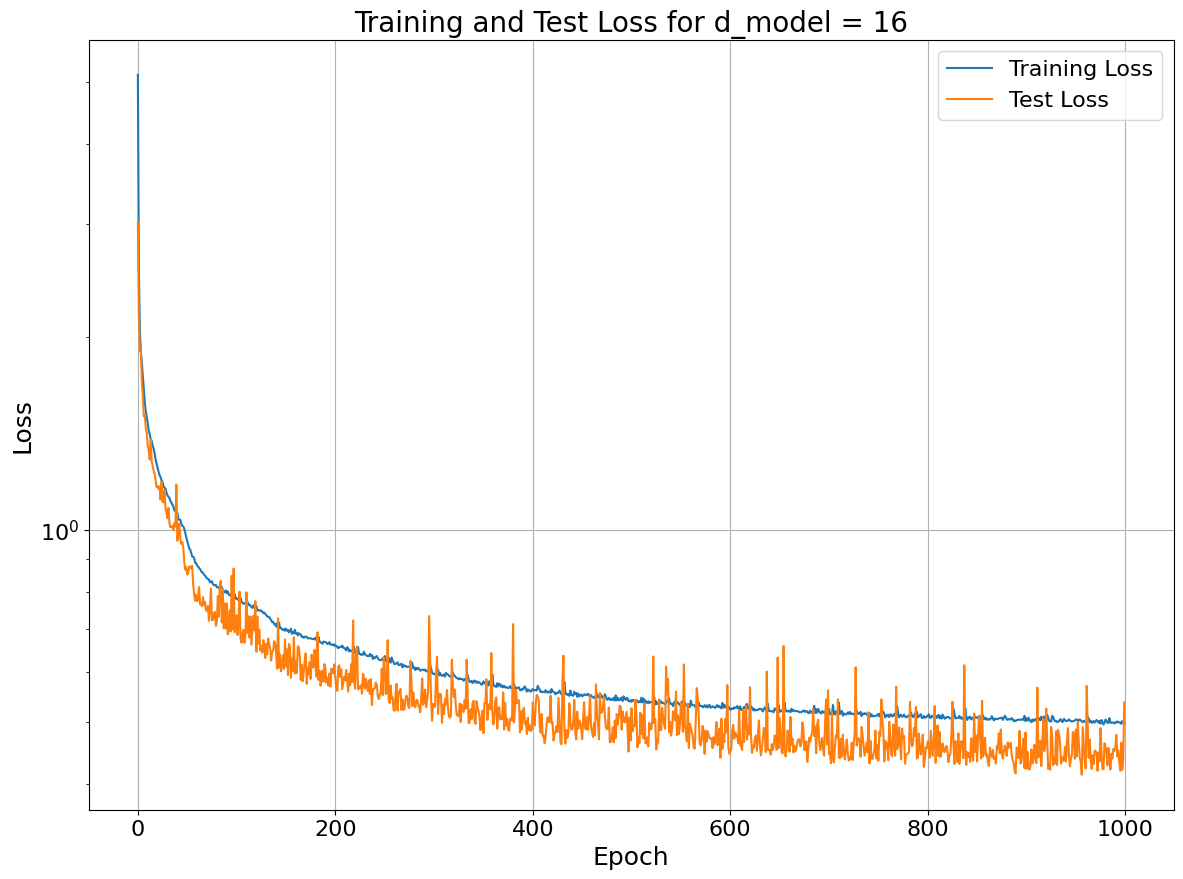

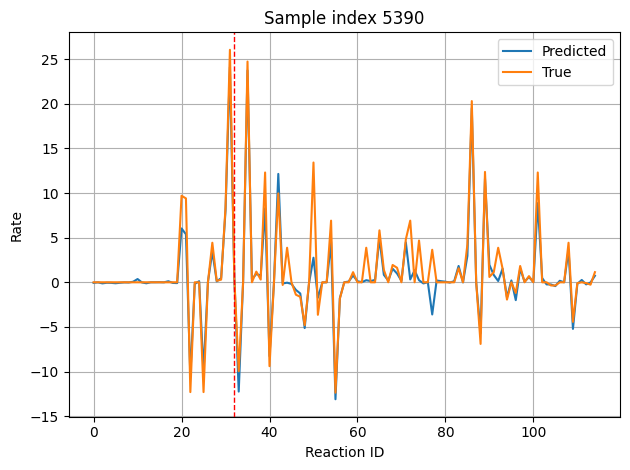

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -75.22247 109.95508
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -75.22247 109.95508
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.28439403 to 2.5994294


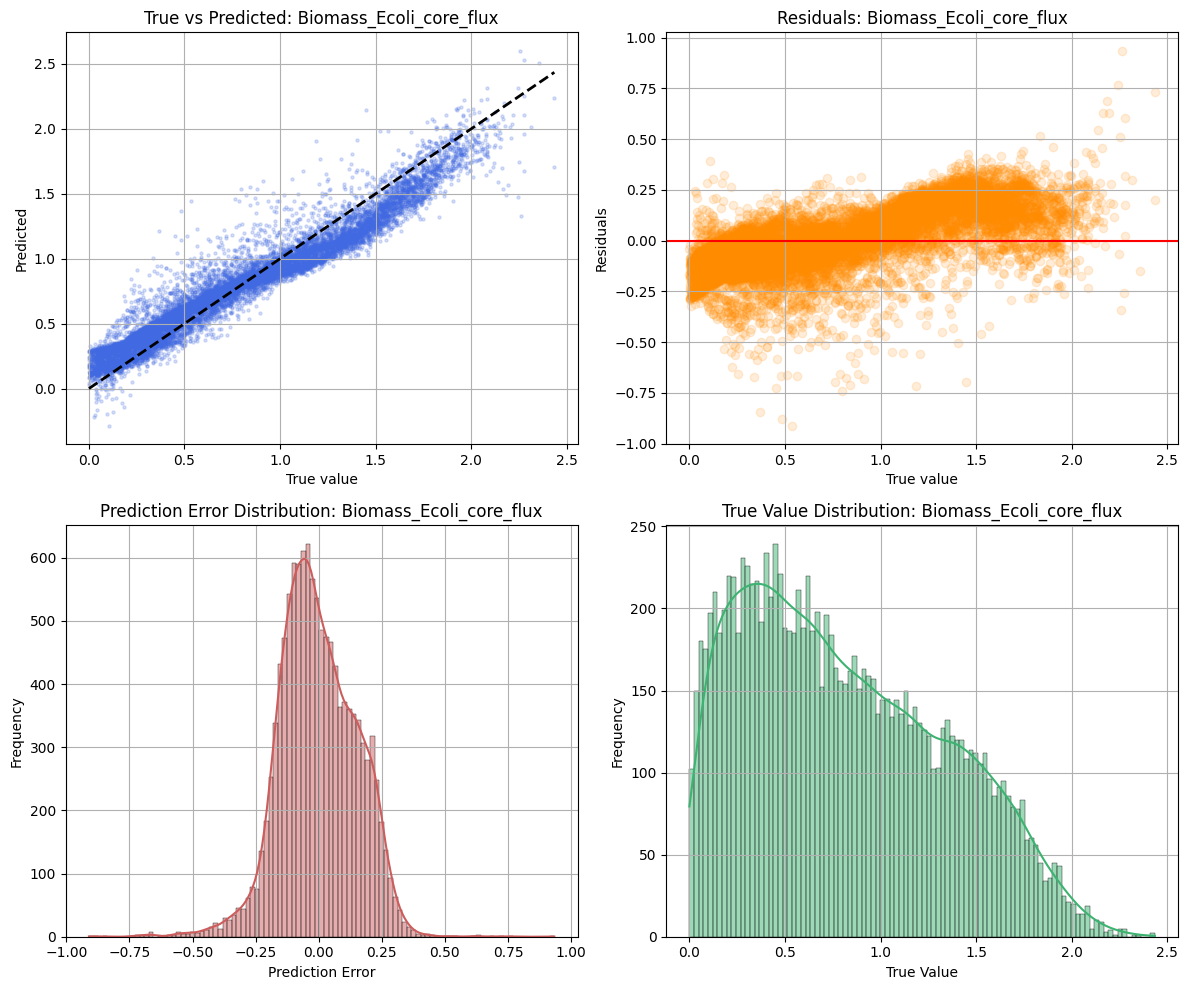

Number of parameters:
9006


In [21]:
train_losses_16_4_2_4, test_losses_16_4_2_4, trained_model_16_4_2_4 = train_model(d_model=16, n_heads=4, n_layers=2, inner_dim_multiplier=4)

plot_loss_curves(train_losses_16_4_2_4, test_losses_16_4_2_4, d_model=16)

plot_prediction_sample(X_test, y_test, trained_model_16_4_2_4)

plot_flux(trained_model_16_4_2_4, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_16_4_2_4.parameters() if p.requires_grad  ))

Epoch 50/1000 | Train Loss: 0.889948 | Test Loss: 0.797379
Epoch 100/1000 | Train Loss: 0.667130 | Test Loss: 0.586582
Epoch 150/1000 | Train Loss: 0.557045 | Test Loss: 0.510276
Epoch 200/1000 | Train Loss: 0.489755 | Test Loss: 0.459820
Epoch 250/1000 | Train Loss: 0.459337 | Test Loss: 0.383519
Epoch 300/1000 | Train Loss: 0.430948 | Test Loss: 0.390582
Epoch 350/1000 | Train Loss: 0.422209 | Test Loss: 0.385033
Epoch 400/1000 | Train Loss: 0.407343 | Test Loss: 0.343483
Epoch 450/1000 | Train Loss: 0.390208 | Test Loss: 0.342890
Epoch 500/1000 | Train Loss: 0.380432 | Test Loss: 0.335452
Epoch 550/1000 | Train Loss: 0.374202 | Test Loss: 0.342326
Epoch 600/1000 | Train Loss: 0.364341 | Test Loss: 0.324267
Epoch 650/1000 | Train Loss: 0.360971 | Test Loss: 0.312955
Epoch 700/1000 | Train Loss: 0.354414 | Test Loss: 0.337060
Epoch 750/1000 | Train Loss: 0.349193 | Test Loss: 0.348371
Epoch 800/1000 | Train Loss: 0.347297 | Test Loss: 0.300323
Epoch 850/1000 | Train Loss: 0.344138 | T

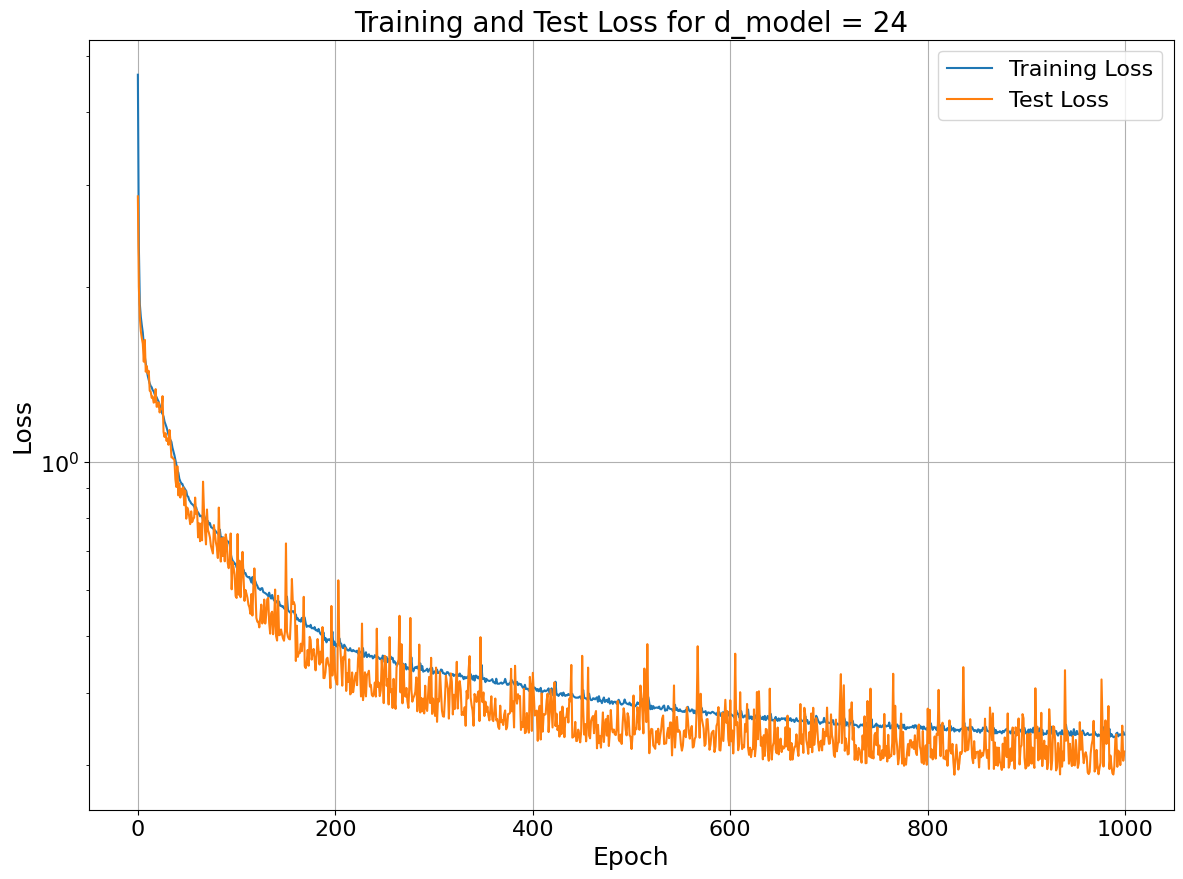

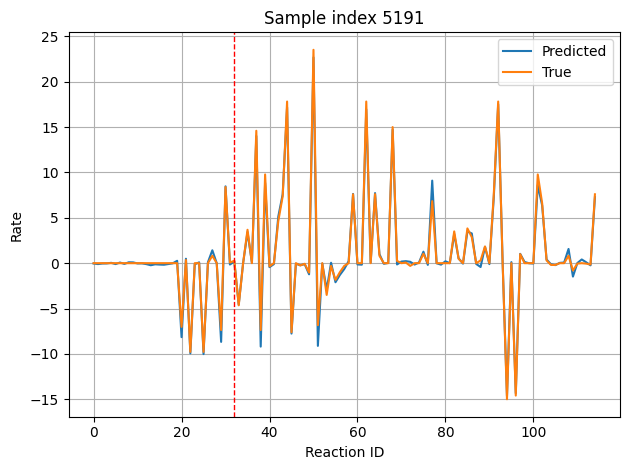

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -78.44263 111.48321
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -78.44263 111.48321
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.27981615 to 4.000025


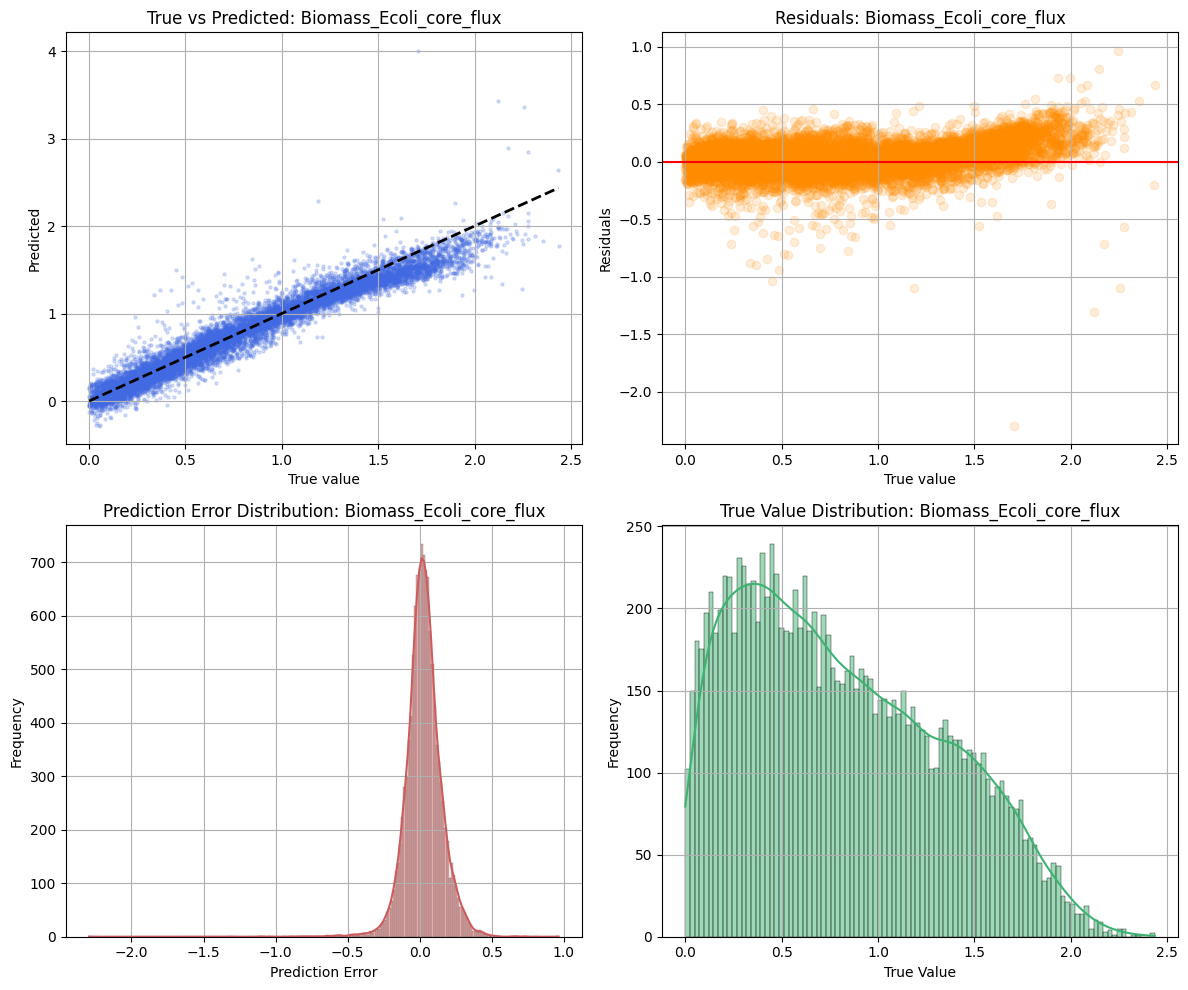

Number of parameters:
23202


In [22]:
train_losses_24_4_2_6, test_losses_24_4_2_6, trained_model_24_4_2_6 = train_model(d_model=24, n_heads=4, n_layers=2, inner_dim_multiplier=6)

plot_loss_curves(train_losses_24_4_2_6, test_losses_24_4_2_6, d_model=24)

plot_prediction_sample(X_test, y_test, trained_model_24_4_2_6)

plot_flux(trained_model_24_4_2_6, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_24_4_2_6.parameters() if p.requires_grad  ))

Epoch 50/1000 | Train Loss: 0.630159 | Test Loss: 0.641089
Epoch 100/1000 | Train Loss: 0.494186 | Test Loss: 0.508409
Epoch 150/1000 | Train Loss: 0.414434 | Test Loss: 0.457498
Epoch 200/1000 | Train Loss: 0.370776 | Test Loss: 0.599472
Epoch 250/1000 | Train Loss: 0.340949 | Test Loss: 0.313177
Epoch 300/1000 | Train Loss: 0.323794 | Test Loss: 0.280027
Epoch 350/1000 | Train Loss: 0.309498 | Test Loss: 0.340122
Epoch 400/1000 | Train Loss: 0.299405 | Test Loss: 0.366742
Epoch 450/1000 | Train Loss: 0.294529 | Test Loss: 0.378996
Epoch 500/1000 | Train Loss: 0.279570 | Test Loss: 0.280216
Epoch 550/1000 | Train Loss: 0.277148 | Test Loss: 0.240350
Epoch 600/1000 | Train Loss: 0.266824 | Test Loss: 0.246317
Epoch 650/1000 | Train Loss: 0.265320 | Test Loss: 0.271036
Epoch 700/1000 | Train Loss: 0.269195 | Test Loss: 0.266658
Epoch 750/1000 | Train Loss: 0.252586 | Test Loss: 0.263488
Epoch 800/1000 | Train Loss: 0.250473 | Test Loss: 0.228555
Epoch 850/1000 | Train Loss: 0.248551 | T

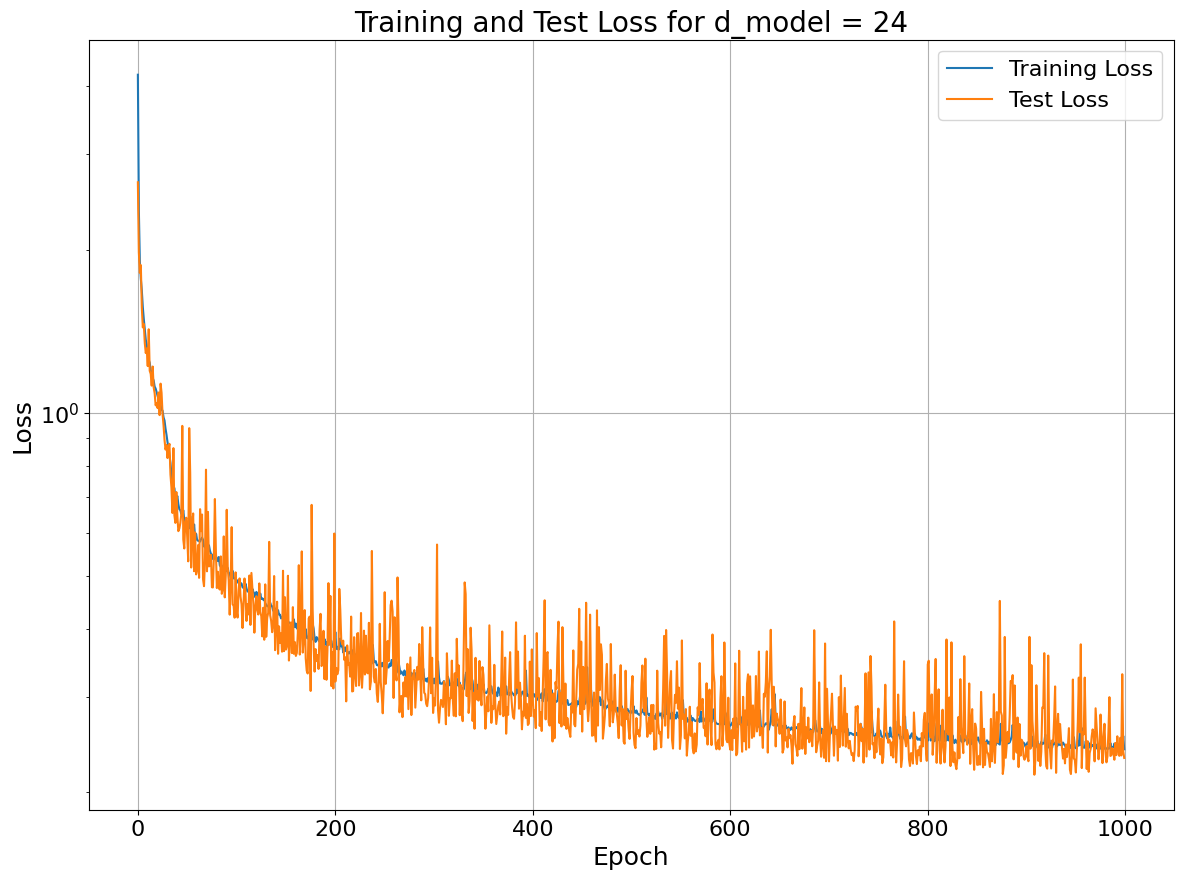

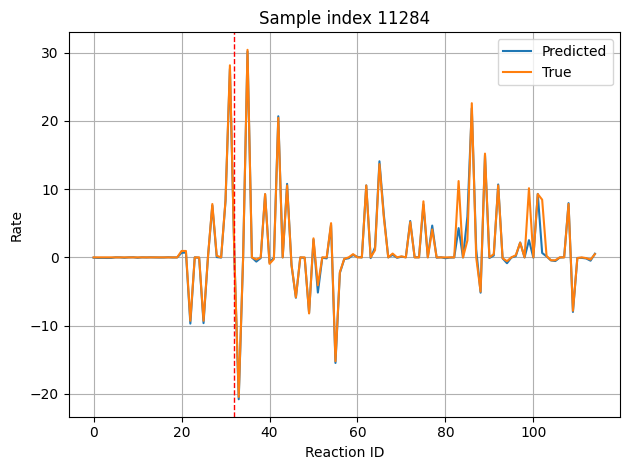

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -78.59392 109.36483
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -78.59392 109.36483
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.19917011 to 2.1846344


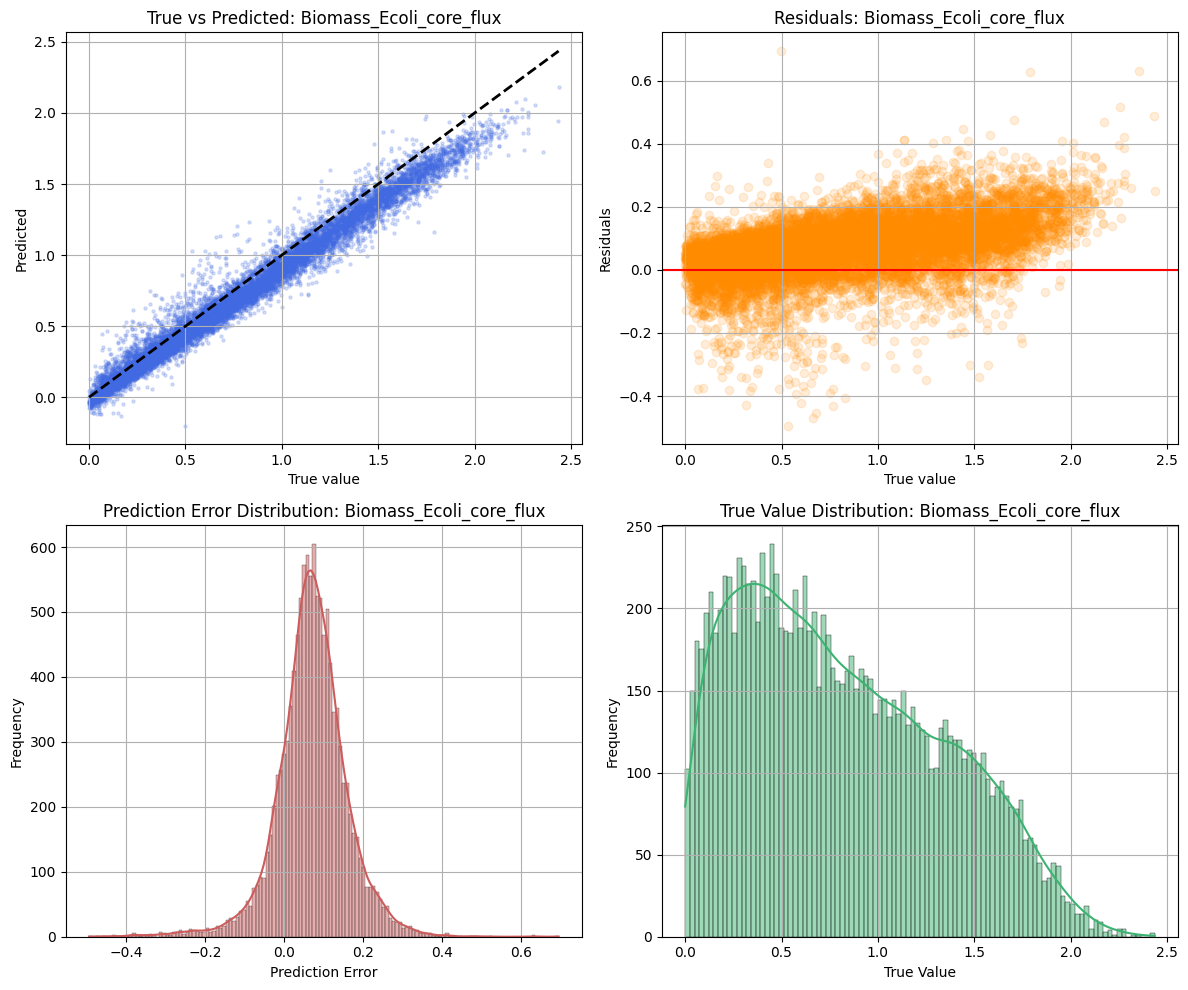

Number of parameters:
33423


In [23]:
train_losses_24_4_3_6, test_losses_24_4_3_6, trained_model_24_4_3_6 = train_model(d_model=24, n_heads=4, n_layers=3, inner_dim_multiplier=6)

plot_loss_curves(train_losses_24_4_3_6, test_losses_24_4_3_6, d_model=24)

plot_prediction_sample(X_test, y_test, trained_model_24_4_3_6)

plot_flux(trained_model_24_4_3_6, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_24_4_3_6.parameters() if p.requires_grad  ))

Epoch 50/1000 | Train Loss: 0.467910 | Test Loss: 0.534599
Epoch 100/1000 | Train Loss: 0.348896 | Test Loss: 0.434184
Epoch 150/1000 | Train Loss: 0.305428 | Test Loss: 0.270759
Epoch 200/1000 | Train Loss: 0.269041 | Test Loss: 0.254125
Epoch 250/1000 | Train Loss: 0.272104 | Test Loss: 0.277048
Epoch 300/1000 | Train Loss: 0.244880 | Test Loss: 0.237757
Epoch 350/1000 | Train Loss: 0.236273 | Test Loss: 0.296140
Epoch 400/1000 | Train Loss: 0.225859 | Test Loss: 0.205635
Epoch 450/1000 | Train Loss: 0.220037 | Test Loss: 0.203726
Epoch 500/1000 | Train Loss: 0.217852 | Test Loss: 0.200863
Epoch 550/1000 | Train Loss: 0.211466 | Test Loss: 0.249817
Epoch 600/1000 | Train Loss: 0.210895 | Test Loss: 0.203061
Epoch 650/1000 | Train Loss: 0.205118 | Test Loss: 0.193604
Epoch 700/1000 | Train Loss: 0.205228 | Test Loss: 0.278950
Epoch 750/1000 | Train Loss: 0.203739 | Test Loss: 0.215803
Epoch 800/1000 | Train Loss: 0.203907 | Test Loss: 0.194402
Epoch 850/1000 | Train Loss: 0.205148 | T

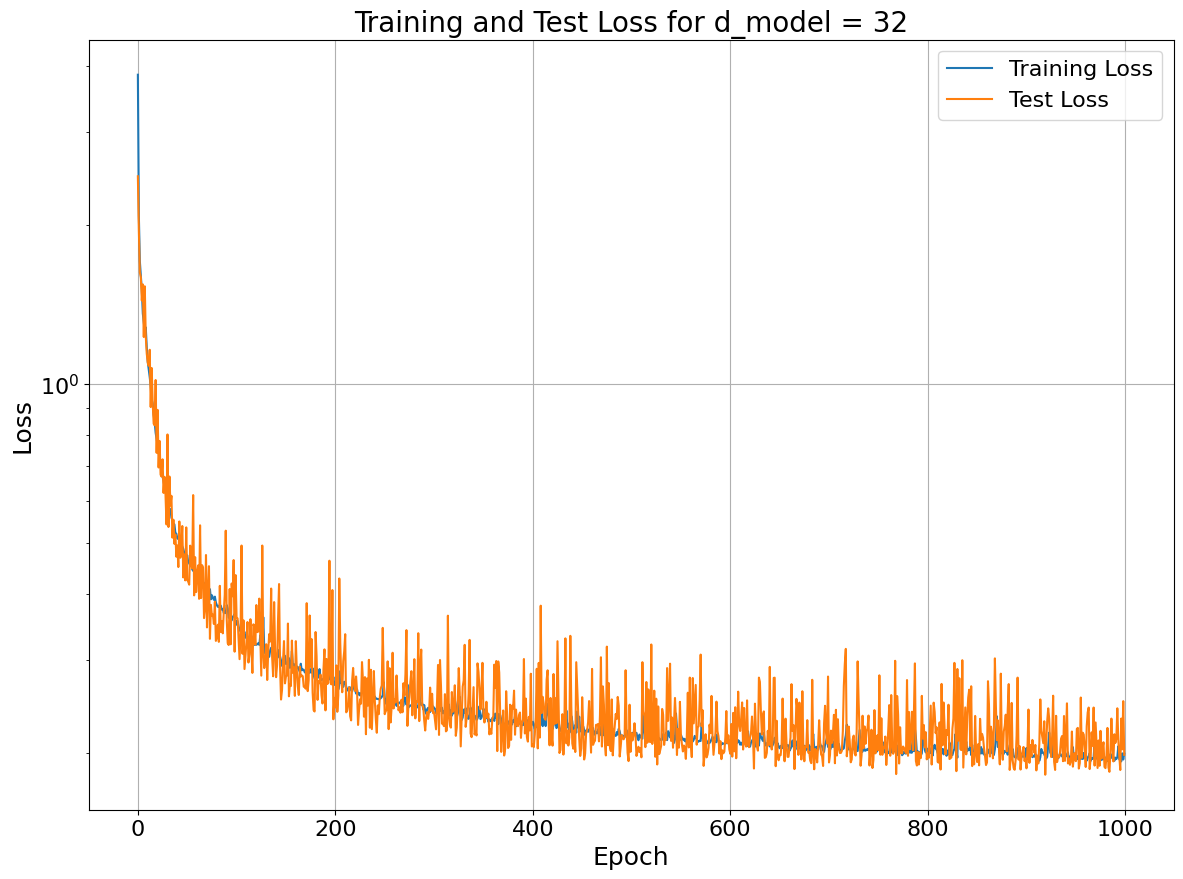

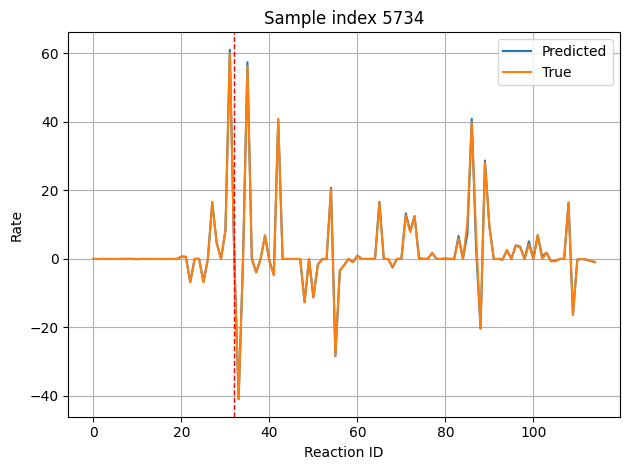

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -76.24475 109.333244
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -76.24475 109.333244
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.19961858 to 2.246045


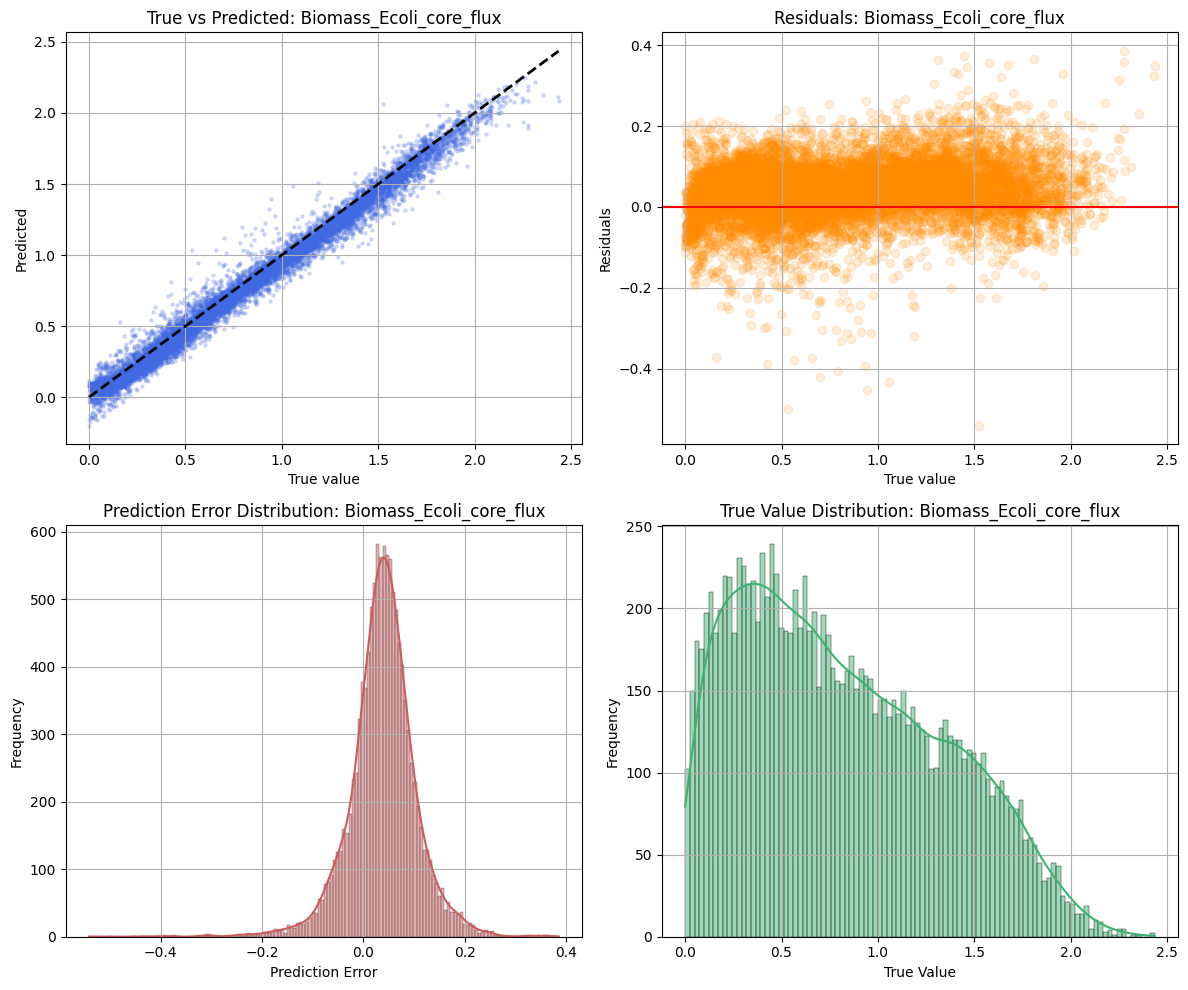

Number of parameters:
70097


In [24]:
train_losses_32_8_3_8, test_losses_32_8_3_8, trained_model_32_8_3_8 = train_model(d_model=32, n_heads=8, n_layers=3, inner_dim_multiplier=8)

plot_loss_curves(train_losses_32_8_3_8, test_losses_32_8_3_8, d_model=32)

plot_prediction_sample(X_test, y_test, trained_model_32_8_3_8)

plot_flux(trained_model_32_8_3_8, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in trained_model_32_8_3_8.parameters() if p.requires_grad  ))